Introduction to Data Science (Part B) 


Dataset used from: https://www.kaggle.com/datasets/datascientistanna/data-dataset 
The dataset was selected because it is a common real-world dataset, which contains both categorical and continuous numerical variables with some missing values. The objective of this analysis is to discover the groups of customer with similar spending behaviours.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline

data = pd.read_csv('PartB_Data.csv')
print("Columns:")
print(data.columns)
print("Column and Row: ",data.shape)
print("Data types of the values:")
print(data.dtypes)
data.head()

Columns:
Index(['ID', 'Gender_Code', 'Region', 'Income', 'Spending'], dtype='object')
Column and Row:  (1113, 5)
Data types of the values:
ID               int64
Gender_Code     object
Region          object
Income         float64
Spending       float64
dtype: object


,ID,Gender_Code,Region,Income,Spending
0,1,Female,Rural,20.0,15.0
1,2,Male,Rural,5.0,12.0
2,3,Female,Urban,28.0,18.0
3,4,Male,Urban,40.0,10.0
4,5,Male,Urban,42.0,9.0


In [30]:
# Missing values
data.isnull().sum()

ID             0
Gender_Code    6
Region         6
Income         6
Spending       5
dtype: int64

In [31]:
# Show rows with missing values in Gender_Code column or Region column.
data[data['Gender_Code'].isnull()| data['Region'].isnull()]

,ID,Gender_Code,Region,Income,Spending
15,16,NaN,Urban,36.0,18.0
20,21,Male,NaN,23.0,11.0
25,26,Female,NaN,11.0,20.0
28,29,NaN,Urban,37.0,17.0
47,48,NaN,Rural,10.0,8.0
51,52,Male,NaN,8.0,14.0
60,61,Female,NaN,26.0,16.0
69,70,NaN,Rural,7.0,19.0
105,106,NaN,Urban,42.0,12.0
109,110,Female,NaN,44.0,7.0


These rows should be removed as they are missing catogorical data, which cannot be replaced using numerical methods such as mean or median. It is removed to preserve data consistency and avoid inaccurate data assumptions.

In [32]:
# Remove rows with missing values in Gender_Code and Region Columns
data = data.dropna(subset=['Gender_Code','Region'])
data.isnull().sum()

ID             0
Gender_Code    0
Region         0
Income         6
Spending       5
dtype: int64

In [36]:
print(data[data['Income'].isnull()])
print(data[data['Spending'].isnull()])

        ID Gender_Code Region  Income  Spending
55      56      Female  Urban     NaN      14.0
70      71        Male  Rural     NaN       6.0
91      92        Male  Urban     NaN      18.0
101    102        Male  Urban     NaN      16.0
112    113      Female  Urban     NaN      11.0
1097  1098      Female  Urban     NaN      11.0
        ID Gender_Code Region  Income  Spending
64      65        Male  Urban    36.0       NaN
77      78        Male  Rural     6.0       NaN
90      91      Female  Urban    34.0       NaN
99     100        Male  Urban    37.0       NaN
1102  1103      Female  Urban    30.0       NaN


Missing values in continuous numerical attributes are replaced with mediam imputation. Median is selected because it is less sensitive to extreme values compared to mean.

In [37]:
# Replace missing value in Column Income and Spending with their median
income_median = data['Income'].median()
spending_median = data['Spending'].median()

data.loc[data['Income'].isnull(), 'Income'] = income_median
data.loc[data['Spending'].isnull(), 'Spending'] = spending_median
data.isnull().sum()

ID             0
Gender_Code    0
Region         0
Income         0
Spending       0
dtype: int64

In [38]:
data.describe()

,ID,Income,Spending
count,1101.000000,1101.000000,1101.000000
mean,560.596730,26.026340,11.238874
std,318.757162,13.318621,4.584180
min,1.000000,5.000000,5.000000
25%,286.000000,14.000000,7.000000
50%,561.000000,25.000000,10.000000
75%,836.000000,37.000000,15.000000
max,1113.000000,50.000000,20.000000


In [40]:
# Ensure there are no faulty values
print(data['Gender_Code'].value_counts())
print(data['Region'].value_counts())

Gender_Code
Male      570
Female    531
Name: count, dtype: int64
Region
Rural    555
Urban    546
Name: count, dtype: int64


In [41]:
# Check for Duplicate Rows
customers.duplicated().sum()

np.int64(0)

After handling missing values, removing unsuitable records and checking duplicates, the dataset became cleaner and more consistent for analysis. These preprocessing steps improved the overall data quality and reduced the risk of inaccurate clustering results.

Text(0.5, 1.0, 'Customer Distribution by Income and Spending Score')

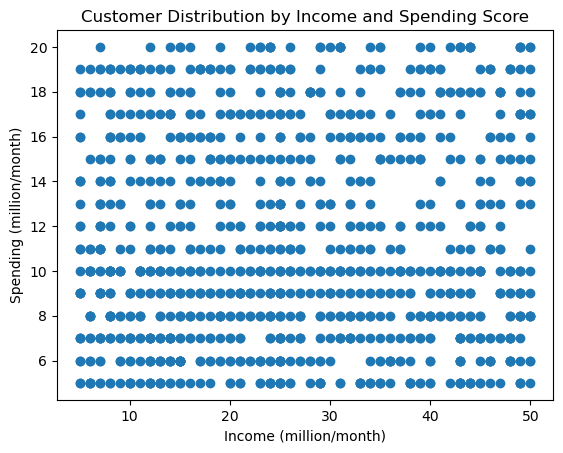

In [42]:
# Visualising
# Scatter plot
plt.scatter(x= data['Income'], y = data['Spending'])
plt.xlabel('Income (million/month)')
plt.ylabel('Spending (million/month)')
plt.title('Customer Distribution by Income and Spending Score')

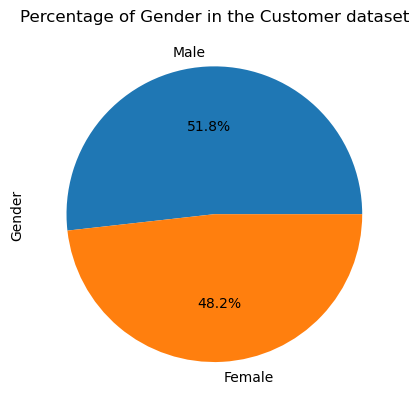

In [49]:
data['Gender_Code'].value_counts().plot.pie(autopct = '%1.1f%%')
plt.title("Percentage of Gender in the Customer dataset")
plt.ylabel("Gender")
plt.show()

In [59]:
from sklearn.preprocessing import StandardScaler

X = data[['Income', 'Spending']]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

C:\Users\eliza\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


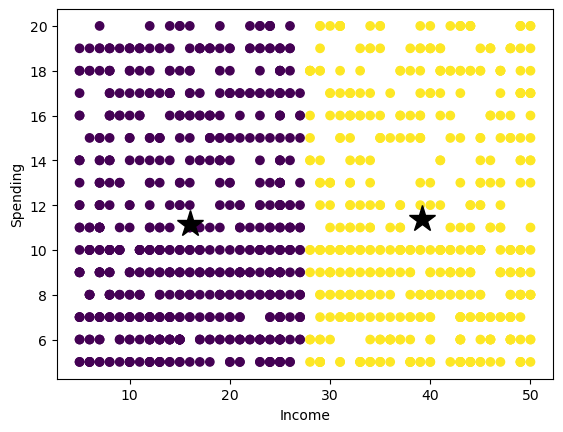

In [60]:
# Clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2).fit(
 data[['Income','Spending']]
)

plt.scatter(
     x=data['Income'],
     y=data['Spending'], 
     c=kmeans.labels_)
# Visualise the cluster centers (black stars)
plt.plot(
     kmeans.cluster_centers_[:,0],
     kmeans.cluster_centers_[:,1],
     'k*',
     markersize=20
)
plt.xlabel('Income')
plt.ylabel('Spending')
plt.show()

C:\Users\eliza\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


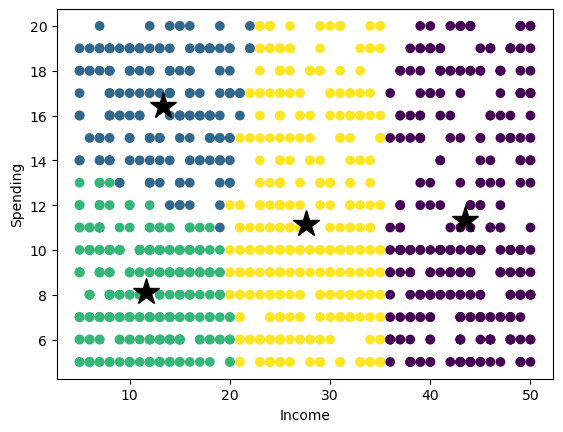

In [61]:
# Clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4).fit(
 data[['Income','Spending']]
)

plt.scatter(
     x=data['Income'],
     y=data['Spending'], 
     c=kmeans.labels_)
# Visualise the cluster centers (black stars)
plt.plot(
     kmeans.cluster_centers_[:,0],
     kmeans.cluster_centers_[:,1],
     'k*',
     markersize=20
)
plt.xlabel('Income')
plt.ylabel('Spending')
plt.show()

C:\Users\eliza\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


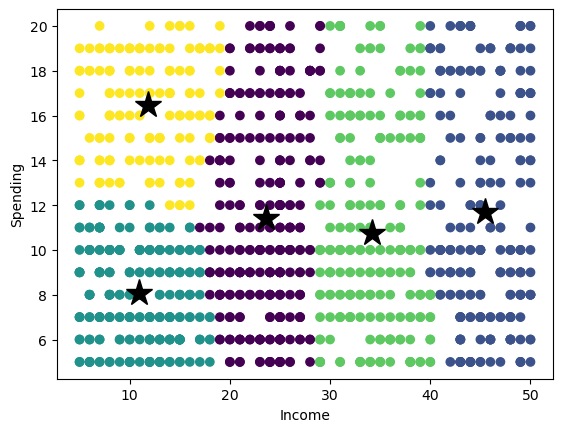

In [68]:
# Clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5).fit(
 data[['Income','Spending']]
)

plt.scatter(
     x=data['Income'],
     y=data['Spending'], 
     c=kmeans.labels_)
# Visualise the cluster centers (black stars)
plt.plot(
     kmeans.cluster_centers_[:,0],
     kmeans.cluster_centers_[:,1],
     'k*',
     markersize=20
)
plt.xlabel('Income')
plt.ylabel('Spending')
plt.show()